In [65]:
#pip install opencv-python

In [328]:
import os
import re
import pandas as pd
import cv2 # opencv library
import numpy as np
from os.path import isfile, join
import matplotlib.pyplot as plt

In [288]:
col_frames = os.listdir('./Webcam Computer Vision/')
col_frames

['camera0 (1).jpg',
 'camera0 (2).jpg',
 'camera0.jpg',
 'GRCA webcam no vehicles 11282022.jpg',
 'GRCA webcam work zone.jpg',
 'Test_nocars.jpg',
 'webcam_output_11142022.jpg',
 'webcam_output_11212022.jpg',
 'webcam_output_11212022_1.jpg',
 'webcam_output_11212022_1_1.jpg']

In [289]:
col_images = []

In [290]:
for i in col_frames:
    # read the frames
    img = cv2.imread('./Webcam Computer Vision/'+i)
    # append the frames to the list
    col_images.append(img)

In [291]:
len(col_images)

10

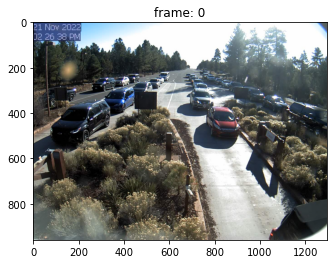

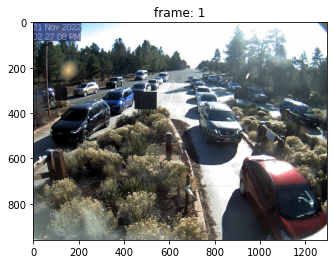

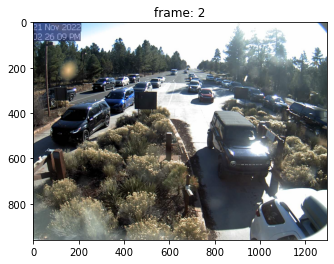

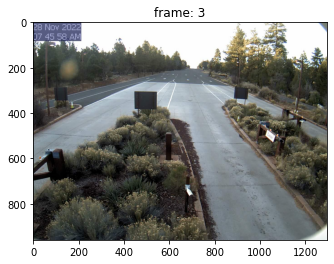

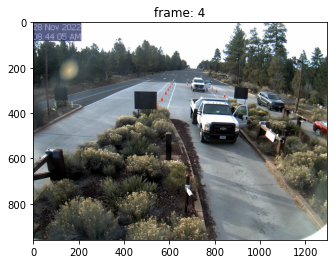

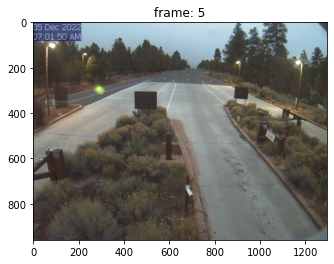

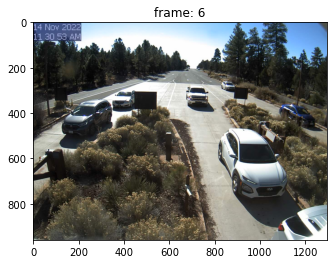

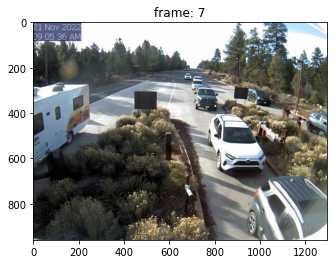

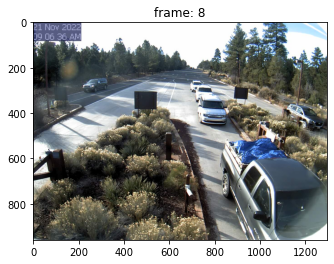

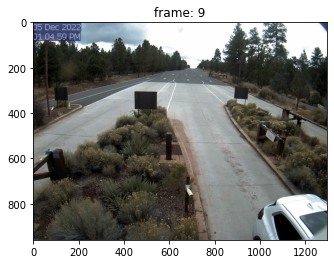

In [294]:
i = 0
for frame in range(i, len(col_images)):
    plt.imshow(cv2.cvtColor(col_images[frame], cv2.COLOR_BGR2RGB))
    plt.title("frame: "+str(frame))
    plt.show()

In [379]:
def vehicle_detection(image): 
    print("Base Image")
    plt.imshow(cv2.cvtColor(col_images[base_nocars], cv2.COLOR_BGR2RGB))
    plt.show()

    print("Image to Analyze")
    plt.imshow(cv2.cvtColor(col_images[to_analyze], cv2.COLOR_BGR2RGB))
    plt.show()

    grayA = cv2.cvtColor(col_images[3], cv2.COLOR_BGR2GRAY)
    grayB = cv2.cvtColor(col_images[to_analyze], cv2.COLOR_BGR2GRAY)


    print("Differencing")
    # plot the image after frame differencing
    plt.imshow(cv2.absdiff(grayB, grayA), cmap = 'gray')
    plt.show()

    diff_image = cv2.absdiff(grayB, grayA)

    # perform image thresholding
    ret, thresh = cv2.threshold(diff_image, 100, 255, cv2.THRESH_BINARY)

    cropped_image = thresh[230:1000,400:1200] # Slicing to crop the image

    # Display the cropped image
    print("Cropped:")
    plt.imshow(cropped_image, cmap = 'gray')
    plt.show()

    # apply image dilation
    kernel = np.ones((3,3),np.uint8)
    kernel

    dilated = cv2.dilate(cropped_image,kernel,iterations = 4)

    # original image
    # -1 loads as-is so if it will be 3 or 4 channel as the original
    image = cropped_image
    # mask defaulting to black for 3-channel and transparent for 4-channel

    #https://stackoverflow.com/questions/15341538/numpy-opencv-2-how-do-i-crop-non-rectangular-region
    mask = np.zeros(image.shape, dtype=np.uint8)
    roi_corners = np.array([[(0,0),(0,180), (180,150), (400,700),(800,700),(800,600),(400,100),(500,100),(800,250),(800,150),(350,0)]], dtype=np.int32)
    # fill the ROI so it doesn't get wiped out when the mask is applied

    #channel_count
    ignore_mask_color = (255,) #*channel_count
    cv2.fillPoly(mask, roi_corners, ignore_mask_color)

    # apply the mask
    masked_image = cv2.bitwise_and(image, mask)

    print("Masked:")
    plt.imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
    plt.show()

    contours, hierarchy = cv2.findContours(masked_image.copy(),cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)

    valid_cntrs = []

    for i,cntr in enumerate(contours):
        x,y,w,h = cv2.boundingRect(cntr)
        area = cv2.contourArea(cntr)         
        if area > 400:  
            valid_cntrs.append(cntr)

    # count of discovered contours        

    dmy = col_images[to_analyze].copy()
    dmy = dmy[230:1000,400:1200]

    print("Contours Drawn:")
    cv2.drawContours(dmy, valid_cntrs, -1, (127,200,0), 2)

    print("Number of Contours: ", len(valid_cntrs))
    if len(valid_cntrs) >0:
        all_contours = np.concatenate(valid_cntrs, axis=0)
        print("Above threshold, vehicles present")
        min_arg = all_contours[all_contours[:,:,1].argmin(axis = 0)][:,:,1].astype(int)
        #print(type(min_arg[[0]]))
        #print(min_arg[[0]])
        min_arg_df = pd.DataFrame(min_arg, columns = ['value']) 
        print("Line starts at y pixel:",min_arg_df.iloc[0]['value'])
        cv2.line(dmy, (0, min_arg_df.iloc[0]['value']),(1200,min_arg_df.iloc[0]['value']),(255, 255, 255))
    else: 
        print("Not above threshold. No Vehicle.")
        
    plt.imshow(dmy)
    plt.show()


Base Image


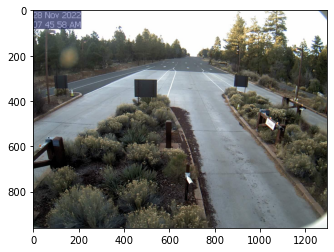

Image to Analyze


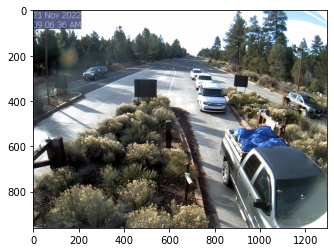

Differencing


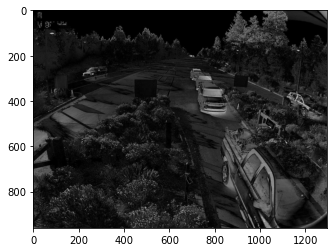

Cropped:


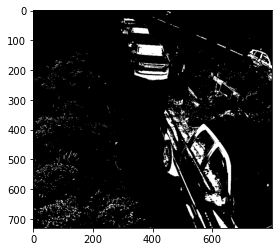

Masked:


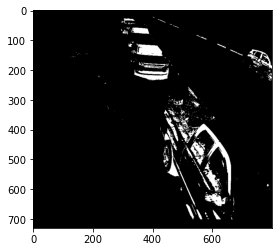

Contours Drawn:
Number of Contours:  12
Above threshold, vehicles present
Line starts at y pixel: 59


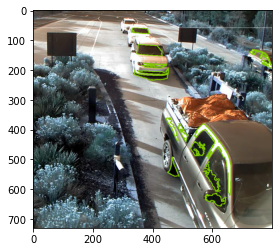

In [380]:
# convert the frames to grayscale
to_analyze = 8
base_nocars = 3
vehicle_detection(to_analyze)